In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

In [3]:
path = 'train.csv'
df = pd.read_csv(path, low_memory=False)

print("Dataset cargado correctamente")

Dataset cargado correctamente


In [ ]:
df_procesado = df.copy()

# Convertimos cada columna de texto a valores numéricos
for col in df_procesado.columns:
    if df_procesado[col].dtype == 'object' or str(df_procesado[col].dtype) == 'string':
        df_procesado[col] = pd.factorize(df_procesado[col])[0]

df_procesado = df_procesado.apply(pd.to_numeric, errors='coerce')


df_procesado = df_procesado.fillna(df_procesado.mean(numeric_only=True))

# Convertimos a matriz y separamos X e y 
datos = df_procesado.values
X = datos[:, :-1]
y = datos[:, -1]

# División 75% Entrenamiento y 25% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Datos para entrenar: {X_train.shape[0]} filas")
print(f"Datos para probar: {X_test.shape[0]} filas")

Datos para entrenar: 1647 filas
Datos para probar: 550 filas


In [6]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar divisiones por cero si alguna columna tiene valores idénticos
    sigma[sigma == 0] = 1e-8 
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos solo X_train y añadimos la columna de unos
X_train_norm, mu, sigma = featureNormalize(X_train)
m_train = X_train_norm.shape[0]
X_train_ready = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)

print("Normalización completada")

Normalización completada


In [7]:
def calcularCosto(X, y, theta):
    m = y.size
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def calcularDescensoGradiente(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_historico = []
    
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_historico.append(calcularCosto(X, y, theta))
        
    return theta, J_historico

In [ ]:
# Buscamos cualquier NaN oculto en X o en y, y lo convertimos en 0 a la fuerza
X_train_seguro = np.nan_to_num(X_train, nan=0.0)
y_train_seguro = np.nan_to_num(y_train, nan=0.0)


# 3. ENTRENAMIENTO
theta_inicial = np.zeros(X_train_ready.shape[1])
alpha = 0.01 # Volvemos al alpha normal porque el problema eran los NaNs
num_iters = 3000

print("Iniciando el entrenamiento blindado contra NaNs...")
theta_optimo, J_historico = calcularDescensoGradiente(X_train_ready, y_train_seguro, theta_inicial, alpha, num_iters)

print(f"Costo final alcanzado: {J_historico[-1]}")

Iniciando el entrenamiento blindado contra NaNs...
Costo final alcanzado: 567634615.694158


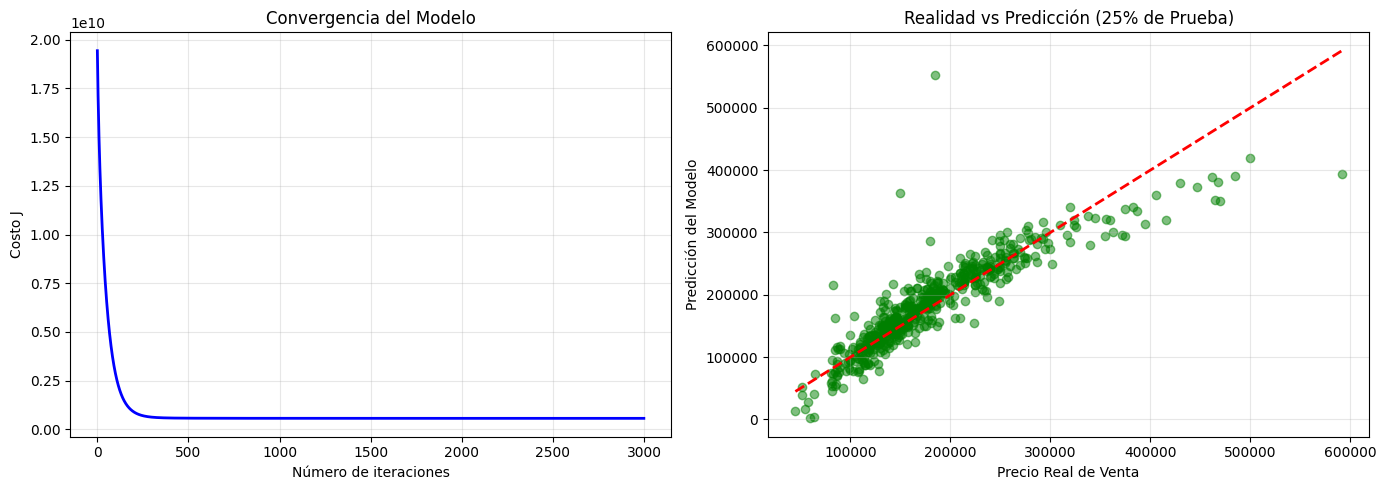

In [11]:
# 1. PARCHE PARA LOS DATOS DE PRUEBA
X_test_seguro = np.nan_to_num(X_test, nan=0.0)
y_test_seguro = np.nan_to_num(y_test, nan=0.0)

# 2. Preparar el 25% de Prueba (Normalizamos usando mu y sigma del entrenamiento)
X_test_norm = (X_test_seguro - mu) / sigma
# Por si la división genera algún error nuevo
X_test_norm = np.nan_to_num(X_test_norm, nan=0.0) 

m_test = X_test_norm.shape[0]
X_test_ready = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

# 3. Hacer predicciones con el modelo entrenado
predicciones_test = np.dot(X_test_ready, theta_optimo)

# 4. Dibujar las gráficas
plt.figure(figsize=(14, 5))

# Gráfica de Costo
plt.subplot(1, 2, 1)
plt.plot(np.arange(len(J_historico)), J_historico, lw=2, color='blue')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Modelo')
plt.grid(True, alpha=0.3)

# Gráfica de Realidad vs Predicción
plt.subplot(1, 2, 2)
plt.scatter(y_test_seguro, predicciones_test, alpha=0.5, color='green')
plt.plot([y_test_seguro.min(), y_test_seguro.max()], [y_test_seguro.min(), y_test_seguro.max()], 'r--', lw=2)
plt.xlabel('Precio Real de Venta')
plt.ylabel('Predicción del Modelo')
plt.title('Realidad vs Predicción (25% de Prueba)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EXPLICACION DEL DATA SET

importacion y carga de datos
llama a las herramientas de trabajo pandas maneja la tabla de datos numpy hace los calculos matematicos rapidos con matrices y matplotlib dibuja luego lee tu archivo
lo que debes saber para tu defensa si te preguntan por que usas numpy en lugar de listas normales de python la respuesta es que numpy usa operaciones vectorizadas lo que permite procesar miles de filas de datos matematicos de forma simultanea y mucho mas rapida
limpieza y division de datos el setenta y cinco veinticinco
los algoritmos matematicos no entienden palabras solo entienden numeros el factorize convierte esas palabras en codigos numericos luego se rellenan los huecos vacios con el promedio numerico de la columna y finalmente separa el dataset
lo que debes saber para tu defensa la division de datos es vital separamos setenta y cinco por ciento para que el algoritmo aprenda y ocultamos un veinticinco por ciento para el examen final nunca debes evaluar un modelo con los mismos datos que uso para entrenar porque eso seria como darle las respuestas del examen antes de tomarlo lo cual es un error conocido como sobreajuste
normalizacion de caracteristicas
aplica una formula matematica llamada estandarizacion toma columnas que tienen numeros gigantes y columnas con numeros pequenos y los comprime todos a una escala pequena
lo que debes saber para tu defensa si el profesor te pregunta por que normalizamos dile que si no normalizamos las caracteristicas con valores muy grandes dominarian la ecuacion y el gradiente explotaria generando errores normalizar crea un terreno de juego nivelado para todas las variables
el motor matematico costo y gradiente
esta es la inteligencia de tu algoritmo la funcion de costo calcula que tan equivocado esta el modelo y el descenso por el gradiente es el mecanismo que corrige ese error usando derivadas parciales para saber hacia donde debe ajustar los pesos theta para equivocarse menos en el siguiente intento la variable alpha decide que tan grandes son los pasos que da para corregirse
el entrenamiento blindado
aplica un parche de seguridad para asegurarse de que no quede ni un solo valor nulo escondido que arruine la matematica luego inicia el ciclo arranca con thetas en cero y los va mejorando tres mil veces usando un tamano de paso de cero con cero uno al final entrega el theta optimo que es la formula magica que aprendio para predecir precios
evaluacion y graficas el examen final
toma el veinticinco por ciento de los datos que estaban escondidos y los normaliza usando la misma media y desviacion estandar que se calculo en el entrenamiento luego multiplica esos datos por la formula aprendida para generar las predicciones por ultimo dibuja la convergencia y que tan cerca estuvieron las predicciones de la realidad
lo que debes saber para tu defensa si el ingeniero te pregunta por que usaste la media y desviacion estandar del entrenamiento en los datos de prueba la respuesta de oro es que los datos de prueba deben ser tratados como informacion nueva y desconocida si calculamos un nuevo promedio usando los datos de prueba estariamos filtrando informacion del futuro hacia nuestro modelo asi que debemos escalarlos usando estrictamente las reglas que el modelo aprendio durante su entrenamiento